In [ ]:
from google.colab import files

# ⬆️ Run this cell → a 'Choose File' button will appear
# Upload your  flower_dataset.csv  file
uploaded = files.upload()

Saving flower data set.zip to flower data set.zip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile

# Get the name of the uploaded zip file
zip_file_name = list(uploaded.keys())[0]

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv('flower_dataset.csv')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'flower_dataset.csv'

In [ ]:
from google.colab import files
import zipfile, os, io

# ⬆️ Upload your zip file here
uploaded = files.upload()

# Unzip automatically
for fname in uploaded.keys():
    if fname.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(uploaded[fname])) as zf:
            zf.extractall('.')          # extract to current directory
            print('✅ Extracted files:', zf.namelist())
    else:
        # Already a CSV — save it directly
        with open(fname, 'wb') as f:
            f.write(uploaded[fname])
        print('✅ File saved:', fname)

print('\nFiles in current directory:', os.listdir('.'))

Saving archive.zip to archive.zip
✅ Extracted files: ['flower_dataset.csv']

Files in current directory: ['.config', 'flower data set (1).zip', 'flower data set.zip', 'archive.zip', 'flower_dataset.csv', 'sample_data']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import glob

# Auto-detect the CSV file (works for any name)
csv_files = glob.glob('*.csv')
if not csv_files:
    raise FileNotFoundError('❌ No CSV found! Make sure Step 1 ran successfully.')

csv_path = csv_files[0]
print('📄 Loading:', csv_path)

df = pd.read_csv(csv_path)
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

📄 Loading: flower_dataset.csv
Shape: (10000, 4)

First 5 rows:


,species,size,fragrance,height_cm
0,rose,medium,mild,48.55
1,shoeblack plant,medium,mild,147.07
2,shoeblack plant,medium,none,102.93
3,hibiscus,large,none,184.00
4,shoeblack plant,large,mild,83.07


Columns: ['species', 'size', 'fragrance', 'height_cm']

Data types:
species       object
size          object
fragrance     object
height_cm    float64
dtype: object

Class distribution:
species
rose               3345
shoeblack plant    3337
hibiscus           3318
Name: count, dtype: int64

Missing values:
species      0
size         0
fragrance    0
height_cm    0
dtype: int64


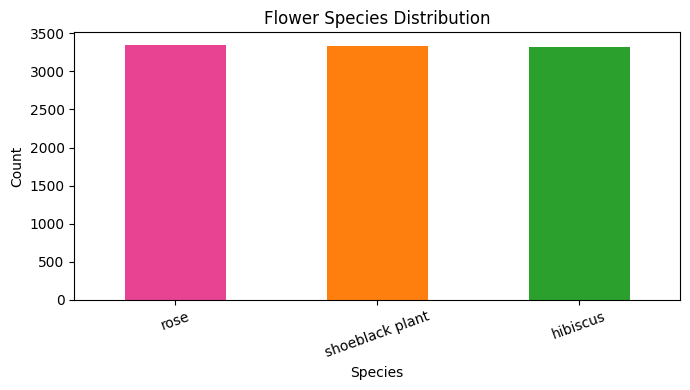

In [ ]:
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nClass distribution:')
print(df['species'].value_counts())
print('\nMissing values:')
print(df.isnull().sum())

# Visualise class distribution
plt.figure(figsize=(7, 4))
df['species'].value_counts().plot(kind='bar', color=['#e84393', '#ff7f0e', '#2ca02c'])
plt.title('Flower Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4a. Encode categorical features ──────────────────────────────────────────
df_enc = df.copy()

# Ordinal-encode 'size'  (small < medium < large)
size_enc = OrdinalEncoder(categories=[['small', 'medium', 'large']])
df_enc['size'] = size_enc.fit_transform(df[['size']])

# Ordinal-encode 'fragrance'  (none < mild < strong)
frag_enc = OrdinalEncoder(categories=[['none', 'mild', 'strong']])
df_enc['fragrance'] = frag_enc.fit_transform(df[['fragrance']])

# Label-encode target
le = LabelEncoder()
y_int = le.fit_transform(df_enc['species'])     # integer labels
y_cat = to_categorical(y_int)                   # one-hot for softmax
num_classes = len(le.classes_)
print('Classes:', le.classes_)
print('Encoded as:', list(range(num_classes)))

# ── 4b. Feature matrix ───────────────────────────────────────────────────────
feature_cols = ['size', 'fragrance', 'height_cm']
X = df_enc[feature_cols].values

# Scale numerical feature (height_cm)
scaler = StandardScaler()
X = scaler.fit_transform(X)

print('\nFeature matrix shape:', X.shape)
print('Label matrix shape  :', y_cat.shape)

Classes: ['hibiscus' 'rose' 'shoeblack plant']
Encoded as: [0, 1, 2]

Feature matrix shape: (10000, 3)
Label matrix shape  : (10000, 3)


In [ ]:
# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_int
)

# ── Reshape to (samples, timesteps=1, features) ───────────────────────────────
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_rnn  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

print('X_train_rnn shape:', X_train_rnn.shape)
print('X_test_rnn  shape:', X_test_rnn.shape)
print('y_train     shape:', y_train.shape)

X_train_rnn shape: (8000, 1, 3)
X_test_rnn  shape: (2000, 1, 3)
y_train     shape: (8000, 3)


In [ ]:
tf.random.set_seed(42)

model = Sequential([
    # RNN layer — 64 units
    SimpleRNN(64,
              activation='tanh',
              input_shape=(1, X_train.shape[1]),   # (timesteps, features)
              return_sequences=False),

    Dropout(0.3),

    # Hidden dense layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer — one node per class, softmax for probabilities
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,531 (25.51 KB)

 Trainable params: 6,531 (25.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_rnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7485 - loss: 0.5771 - val_accuracy: 0.8517 - val_loss: 0.3557
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8737 - loss: 0.3238 - val_accuracy: 0.8875 - val_loss: 0.2688
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8896 - loss: 0.2749 - val_accuracy: 0.8983 - val_loss: 0.2381
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8994 - loss: 0.2549 - val_accuracy: 0.8967 - val_loss: 0.2279
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8975 - loss: 0.2453 - val_accuracy: 0.8992 - val_loss: 0.2200
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8954 - loss: 0.2446 - val_accuracy: 0.8950 - val_loss: 0.2164
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9012 - loss: 0.2365 - val_accuracy: 0.8942 - val_loss: 0.2161
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8996 - loss: 0.2307 - val_acc

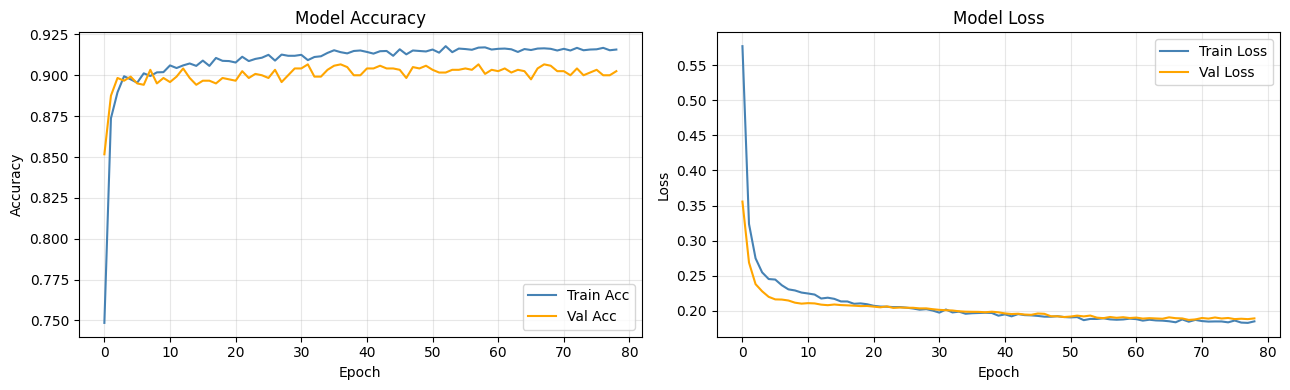

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_rnn, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')

# Predictions
y_pred_prob = model.predict(X_test_rnn)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

Test Loss     : 0.1900
Test Accuracy : 91.10%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report:
                 precision    recall  f1-score   support

       hibiscus       0.88      1.00      0.94       664
           rose       0.89      0.99      0.94       669
shoeblack plant       0.98      0.75      0.85       667

       accuracy                           0.91      2000
      macro avg       0.92      0.91      0.91      2000
   weighted avg       0.92      0.91      0.91      2000



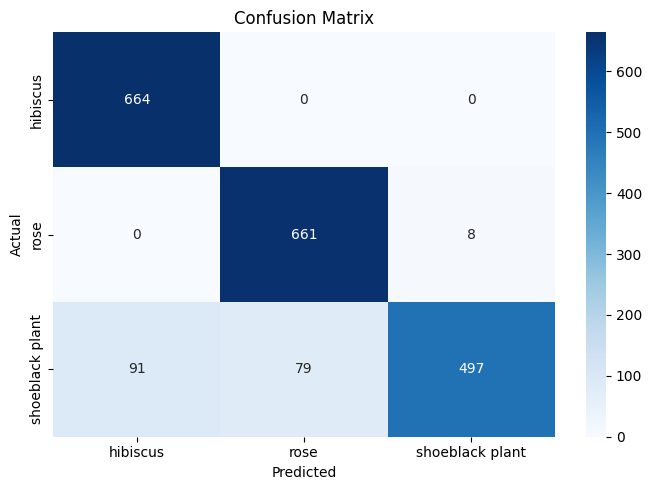

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# ── Edit the values below to test any flower ──────────────────────────────────
new_sample = {
    'size':       'medium',    # small / medium / large
    'fragrance':  'mild',      # none / mild / strong
    'height_cm':   50.0
}

# Encode
size_val  = size_enc.transform([[new_sample['size']]])[0][0]
frag_val  = frag_enc.transform([[new_sample['fragrance']]])[0][0]
height_val = new_sample['height_cm']

# Scale & reshape
sample_arr = np.array([[size_val, frag_val, height_val]])
sample_scaled = scaler.transform(sample_arr)
sample_rnn    = sample_scaled.reshape(1, 1, 3)   # (1 sample, 1 timestep, 3 features)

# Predict
probs = model.predict(sample_rnn)[0]
pred_class = le.classes_[np.argmax(probs)]

print('Input sample  :', new_sample)
print('\nPredicted species:', pred_class)
print('\nClass probabilities:')
for cls, p in zip(le.classes_, probs):
    print(f'  {cls:20s}: {p*100:.1f}%')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
Input sample  : {'size': 'medium', 'fragrance': 'mild', 'height_cm': 50.0}

Predicted species: rose

Class probabilities:
  hibiscus            : 0.0%
  rose                : 78.6%
  shoeblack plant     : 21.4%
